In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


In [2]:
# ============================================================
# IMPORTING LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# LOADING DATASET
# ============================================================

print("===== LOADING DATASET =====")

# Path to October dataset
oct_path = "/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv"

# Number of rows to use
N_ROWS = 6_000_000

# Read dataset in chunks to avoid loading all 42+ million rows
chunks = []
rows_loaded = 0

for chunk in pd.read_csv(
    oct_path,
    chunksize=500_000
):
    
    remaining = N_ROWS - rows_loaded
    
    if len(chunk) <= remaining:
        chunks.append(chunk)
        rows_loaded += len(chunk)
    else:
        chunks.append(chunk.iloc[:remaining])
        rows_loaded += remaining
    
    if rows_loaded >= N_ROWS:
        break

# Combine selected chunks
df = pd.concat(
    chunks,
    ignore_index=True
)

# Release temporary chunks
del chunks

print("\n===== DATASET LOADED SUCCESSFULLY =====")
print("Dataset shape:", df.shape)
print("Number of rows:", f"{df.shape[0]:,}")
print("Number of columns:", df.shape[1])

print("\n===== FIRST 5 ROWS =====")
display(df.head())

===== LOADING DATASET =====

===== DATASET LOADED SUCCESSFULLY =====
Dataset shape: (6000000, 9)
Number of rows: 6,000,000
Number of columns: 9

===== FIRST 5 ROWS =====


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [4]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

print("===== EXPLORATORY DATA ANALYSIS =====")

# ------------------------------------------------------------
# DATASET SHAPE
# ------------------------------------------------------------

print("\n===== DATASET SHAPE =====")

print("Number of rows    :", f"{df.shape[0]:,}")
print("Number of columns :", df.shape[1])


# ------------------------------------------------------------
# FIRST 5 ROWS
# ------------------------------------------------------------

print("\n===== FIRST 5 ROWS =====")

display(df.head())


# ------------------------------------------------------------
# DATASET INFORMATION
# ------------------------------------------------------------

print("\n===== DATASET INFO =====")

df.info()

===== EXPLORATORY DATA ANALYSIS =====

===== DATASET SHAPE =====
Number of rows    : 6,000,000
Number of columns : 9

===== FIRST 5 ROWS =====


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d



===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 412.0+ MB


In [5]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("===== DESCRIPTIVE STATISTICS =====")

display(df.describe())

===== DESCRIPTIVE STATISTICS =====


,product_id,category_id,price,user_id
count,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06
mean,9.856941e+06,2.056491e+18,2.986332e+02,5.314491e+08
std,1.110506e+07,1.634106e+16,3.661892e+02,1.698568e+07
min,1.001588e+06,2.053014e+18,0.000000e+00,1.835035e+08
25%,1.005115e+06,2.053014e+18,6.667000e+01,5.155535e+08
50%,4.804055e+06,2.053014e+18,1.668000e+02,5.270588e+08
75%,1.520011e+07,2.053014e+18,3.704100e+02,5.483944e+08
max,5.560001e+07,2.175420e+18,2.574070e+03,5.571017e+08


In [6]:
# ============================================================
# MISSING VALUES
# ============================================================

print("===== MISSING VALUES =====")

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_values)

===== MISSING VALUES =====


,Missing Values,Percentage
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_id,0,0.00
category_code,1858828,30.98
brand,822626,13.71
price,0,0.00
user_id,0,0.00
user_session,0,0.00


In [7]:
# ============================================================
# DUPLICATE RECORDS
# ============================================================

print("===== DUPLICATE RECORDS =====")

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Number of duplicate rows :", f"{duplicate_count:,}")
print("Duplicate percentage     :", f"{duplicate_percentage:.2f}%")

===== DUPLICATE RECORDS =====
Number of duplicate rows : 3,779
Duplicate percentage     : 0.06%


In [8]:
# ============================================================
# EVENT TYPE DISTRIBUTION
# ============================================================

print("===== EVENT TYPE DISTRIBUTION =====")

event_distribution = pd.DataFrame({
    "Count": df["event_type"].value_counts(),
    "Percentage": (
        df["event_type"].value_counts(normalize=True) * 100
    ).round(2)
})

display(event_distribution)

===== EVENT TYPE DISTRIBUTION =====


,Count,Percentage
event_type,,
view,5768080,96.13
cart,127027,2.12
purchase,104893,1.75


In [9]:
# ============================================================
# REMOVE DUPLICATE RECORDS
# ============================================================

print("===== REMOVING DUPLICATES =====")

before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(df)

removed_duplicates = before_duplicates - after_duplicates

print("Rows before removing duplicates :", f"{before_duplicates:,}")
print("Duplicates removed             :", f"{removed_duplicates:,}")
print("Rows after removing duplicates  :", f"{after_duplicates:,}")

===== REMOVING DUPLICATES =====
Rows before removing duplicates : 6,000,000
Duplicates removed             : 3,779
Rows after removing duplicates  : 5,996,221


In [10]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

print("===== HANDLING MISSING VALUES =====")

df["brand"] = df["brand"].fillna("unknown")
df["category_code"] = df["category_code"].fillna("unknown")

print("\nMissing values after replacement:")
print(df[["brand", "category_code"]].isna().sum())

===== HANDLING MISSING VALUES =====

Missing values after replacement:
brand            0
category_code    0
dtype: int64


===== EVENT TYPE DISTRIBUTION AFTER CLEANING =====


,Count,Percentage
event_type,,
view,5767752,96.19
cart,123581,2.06
purchase,104888,1.75


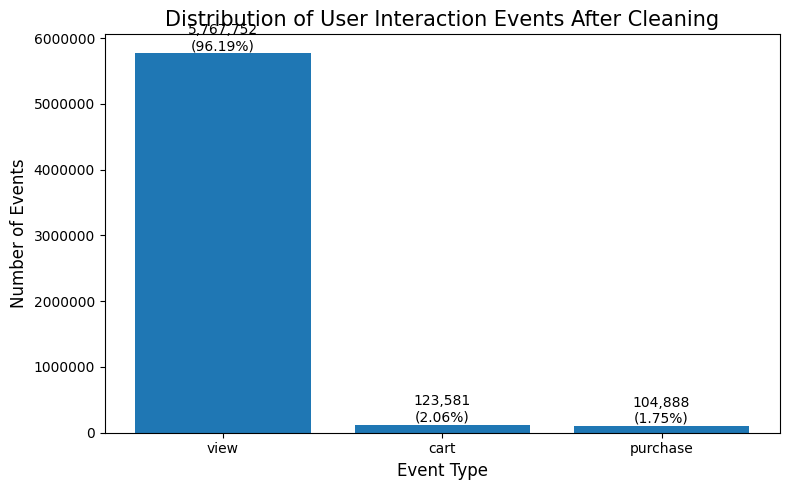

In [11]:
# ============================================================
# EVENT TYPE DISTRIBUTION AFTER CLEANING
# ============================================================

print("===== EVENT TYPE DISTRIBUTION AFTER CLEANING =====")

event_counts_clean = df["event_type"].value_counts()
event_percentages_clean = (
    df["event_type"].value_counts(normalize=True) * 100
).round(2)

event_distribution_clean = pd.DataFrame({
    "Count": event_counts_clean,
    "Percentage": event_percentages_clean
})

display(event_distribution_clean)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    event_distribution_clean.index,
    event_distribution_clean["Count"]
)

plt.title(
    "Distribution of User Interaction Events After Cleaning",
    fontsize=15
)

plt.xlabel("Event Type", fontsize=12)
plt.ylabel("Number of Events", fontsize=12)

plt.ticklabel_format(
    axis="y",
    style="plain"
)

for bar, percentage in zip(
    bars,
    event_distribution_clean["Percentage"]
):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_1_Event_Distribution_After_Cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# CONVERT EVENT TIME
# ============================================================

print("===== CONVERTING EVENT TIME =====")

df["event_time"] = pd.to_datetime(
    df["event_time"],
    utc=True
)

print("event_time dtype:", df["event_time"].dtype)
print("First event time:", df["event_time"].min())
print("Last event time :", df["event_time"].max())

===== CONVERTING EVENT TIME =====
event_time dtype: datetime64[ns, UTC]
First event time: 2019-10-01 00:00:00+00:00
Last event time : 2019-10-05 16:25:48+00:00


In [13]:
# ============================================================
# CHRONOLOGICAL SORTING
# ============================================================

print("===== CHRONOLOGICAL SORTING =====")

df = df.sort_values(
    ["user_session", "event_time"],
    kind="stable"
).reset_index(drop=True)

print("First event time:", df["event_time"].min())
print("Last event time :", df["event_time"].max())

# Check chronological order within each user session
chronological_check = (
    df.groupby("user_session")["event_time"]
      .apply(lambda x: x.is_monotonic_increasing)
      .all()
)

print(
    "Chronological order within sessions:",
    chronological_check
)

===== CHRONOLOGICAL SORTING =====
First event time: 2019-10-01 00:00:00+00:00
Last event time : 2019-10-05 16:25:48+00:00
Chronological order within sessions: True


In [15]:
# ============================================================
# ENCODING EVENT TYPES
# ============================================================

print("===== ENCODING EVENT TYPES =====")

event_mapping = {
    "view": 0,
    "cart": 1,
    "purchase": 2
}

df["event_code"] = df["event_type"].map(event_mapping)

print("\nEvent mapping:")
for event, code in event_mapping.items():
    print(f"{event} -> {code}")

print("\nEncoded event distribution:")
print(df["event_code"].value_counts().sort_index())

print("\nMissing encoded values:", df["event_code"].isna().sum())

===== ENCODING EVENT TYPES =====

Event mapping:
view -> 0
cart -> 1
purchase -> 2

Encoded event distribution:
event_code
0    5767752
1     123581
2     104888
Name: count, dtype: int64

Missing encoded values: 0


In [16]:
# ============================================================
# USER SESSION ANALYSIS
# ============================================================

print("===== USER SESSION ANALYSIS =====")

number_of_sessions = df["user_session"].nunique()

print("Number of unique sessions:", f"{number_of_sessions:,}")

session_lengths = df.groupby("user_session").size()

print("\nSession length statistics:")
print(session_lengths.describe())

print("\nSessions with at least 6 events:",
      (session_lengths >= 6).sum())

===== USER SESSION ANALYSIS =====
Number of unique sessions: 1,289,469

Session length statistics:
count    1.289469e+06
mean     4.650147e+00
std      6.731473e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      6.880000e+02
dtype: float64

Sessions with at least 6 events: 309428


In [17]:
# ============================================================
# CREATION OF SEQUENTIAL DATA
# ============================================================

SEQUENCE_LENGTH = 5

print("===== CREATING SEQUENCES =====")
print("Sequence length:", SEQUENCE_LENGTH)
print("Prediction task: 5 previous events -> next event")

# Number of possible sequences
valid_sessions = session_lengths[session_lengths >= SEQUENCE_LENGTH + 1]

total_sequences = (
    valid_sessions - SEQUENCE_LENGTH
).sum()

print("Sessions available for sequence creation:",
      f"{len(valid_sessions):,}")

print("Total possible sequences:",
      f"{total_sequences:,}")

===== CREATING SEQUENCES =====
Sequence length: 5
Prediction task: 5 previous events -> next event
Sessions available for sequence creation: 309,428
Total possible sequences: 2,360,318


In [18]:
# ============================================================
# BUILD SEQUENTIAL DATA
# ============================================================

print("===== BUILDING SEQUENCES =====")

SEQUENCE_LENGTH = 5

X_sequences = np.empty(
    (total_sequences, SEQUENCE_LENGTH),
    dtype=np.int8
)

y_sequences = np.empty(
    total_sequences,
    dtype=np.int8
)

target_times = np.empty(
    total_sequences,
    dtype="datetime64[ns]"
)

sequence_index = 0

for session_id, group in df.groupby("user_session", sort=False):

    events = group["event_code"].to_numpy(dtype=np.int8)
    times = group["event_time"].dt.tz_localize(None).to_numpy(
        dtype="datetime64[ns]"
    )

    session_length = len(events)

    if session_length <= SEQUENCE_LENGTH:
        continue

    number_of_sequences = session_length - SEQUENCE_LENGTH

    end_index = sequence_index + number_of_sequences

    for i in range(number_of_sequences):

        X_sequences[
            sequence_index + i
        ] = events[i:i + SEQUENCE_LENGTH]

        y_sequences[
            sequence_index + i
        ] = events[i + SEQUENCE_LENGTH]

        target_times[
            sequence_index + i
        ] = times[i + SEQUENCE_LENGTH]

    sequence_index = end_index


print("\n===== SEQUENCES CREATED =====")

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)
print("Target times shape:", target_times.shape)

print("\nExpected sequences:",
      f"{total_sequences:,}")

print("Created sequences:",
      f"{sequence_index:,}")

===== BUILDING SEQUENCES =====

===== SEQUENCES CREATED =====
X shape: (2360318, 5)
y shape: (2360318,)
Target times shape: (2360318,)

Expected sequences: 2,360,318
Created sequences: 2,360,318


In [19]:
 # ============================================================
# SEQUENCE VALIDATION
# ============================================================

print("===== SEQUENCE VALIDATION =====")

# ------------------------------------------------------------
# BASIC SHAPES
# ------------------------------------------------------------

print("\n===== BASIC SHAPES =====")
print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

# ------------------------------------------------------------
# FIRST 10 SEQUENCES
# ------------------------------------------------------------

print("\n===== FIRST 10 SEQUENCES =====")

for i in range(10):
    print(
        f"Sequence {i+1}: "
        f"{X_sequences[i].tolist()} -> Target: {y_sequences[i]}"
    )

# ------------------------------------------------------------
# TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n===== TARGET DISTRIBUTION =====")

target_counts = pd.Series(
    y_sequences
).value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Event": ["view", "cart", "purchase"],
    "Code": [0, 1, 2],
    "Count": [
        target_counts.get(0, 0),
        target_counts.get(1, 0),
        target_counts.get(2, 0)
    ]
})

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(y_sequences)
    * 100
).round(2)

display(target_distribution)

# ------------------------------------------------------------
# CHRONOLOGICAL ORDER OF TARGET TIMES
# ------------------------------------------------------------

print("\n===== TARGET TIME ORDER =====")

chronological_targets = (
    np.all(target_times[:-1] <= target_times[1:])
)

print(
    "Target times chronological:",
    chronological_targets
)

print("First target time:", target_times[0])
print("Last target time :", target_times[-1])

# ------------------------------------------------------------
# TARGET TIME RANGE
# ------------------------------------------------------------

print("\n===== TARGET TIME RANGE =====")

print(
    "Target period:",
    target_times[0],
    "->",
    target_times[-1]
)

# ------------------------------------------------------------
# SEQUENCE VALIDATION SUMMARY
# ------------------------------------------------------------

print("\n===== VALIDATION SUMMARY =====")

print(
    "Correct sequence length:",
    X_sequences.shape[1] == SEQUENCE_LENGTH
)

print(
    "Matching X/y samples:",
    X_sequences.shape[0] == y_sequences.shape[0]
)

print(
    "No missing targets:",
    not np.isnan(y_sequences).any()
)

print(
    "Chronological target order:",
    chronological_targets
)

print("\n===== SEQUENCE VALIDATION COMPLETED =====")

===== SEQUENCE VALIDATION =====

===== BASIC SHAPES =====
X shape: (2360318, 5)
y shape: (2360318,)

===== FIRST 10 SEQUENCES =====
Sequence 1: [0, 0, 0, 0, 0] -> Target: 0
Sequence 2: [0, 0, 0, 0, 0] -> Target: 0
Sequence 3: [0, 0, 0, 0, 0] -> Target: 0
Sequence 4: [0, 0, 0, 0, 0] -> Target: 0
Sequence 5: [0, 0, 0, 0, 0] -> Target: 0
Sequence 6: [0, 0, 0, 0, 0] -> Target: 0
Sequence 7: [0, 0, 0, 0, 0] -> Target: 0
Sequence 8: [0, 0, 0, 0, 0] -> Target: 0
Sequence 9: [0, 0, 0, 0, 0] -> Target: 0
Sequence 10: [0, 0, 0, 0, 0] -> Target: 0

===== TARGET DISTRIBUTION =====


,Event,Code,Count,Percentage
0,view,0,2278353,96.53
1,cart,1,43274,1.83
2,purchase,2,38691,1.64



===== TARGET TIME ORDER =====
Target times chronological: False
First target time: 2019-10-02T17:11:35.000000000
Last target time : 2019-10-03T18:24:19.000000000

===== TARGET TIME RANGE =====
Target period: 2019-10-02T17:11:35.000000000 -> 2019-10-03T18:24:19.000000000

===== VALIDATION SUMMARY =====
Correct sequence length: True
Matching X/y samples: True
No missing targets: True
Chronological target order: False

===== SEQUENCE VALIDATION COMPLETED =====


In [20]:
# ============================================================
# SORT SEQUENCES CHRONOLOGICALLY
# ============================================================

print("===== SORTING SEQUENCES CHRONOLOGICALLY =====")

# Get chronological order based on target time
sequence_order = np.argsort(target_times)

# Reorder sequences, targets and target times
X_sequences = X_sequences[sequence_order]
y_sequences = y_sequences[sequence_order]
target_times = target_times[sequence_order]

print("\n===== CHRONOLOGICAL SORT COMPLETED =====")

print("First target time:", target_times[0])
print("Last target time :", target_times[-1])

# Verify chronological order
chronological_targets = np.all(
    target_times[:-1] <= target_times[1:]
)

print(
    "Target times chronological:",
    chronological_targets
)

===== SORTING SEQUENCES CHRONOLOGICALLY =====

===== CHRONOLOGICAL SORT COMPLETED =====
First target time: 2019-10-01T00:02:41.000000000
Last target time : 2019-10-05T16:25:48.000000000
Target times chronological: True


In [21]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# TIMESTAMP-AWARE SPLIT
# ============================================================

print("===== CHRONOLOGICAL TRAIN / TEST SPLIT =====")

# ------------------------------------------------------------
# Target times are already chronologically sorted
# ------------------------------------------------------------

n_sequences = len(X_sequences)

# Desired 80% position
desired_split_index = int(n_sequences * 0.80)

# Find the target time around the desired 80% boundary
split_time = target_times[desired_split_index]

# ------------------------------------------------------------
# IMPORTANT:
# All sequences with the same target timestamp stay
# in the same dataset.
# ------------------------------------------------------------

train_mask = target_times < split_time
test_mask = target_times >= split_time

# ------------------------------------------------------------
# Create train/test sets
# ------------------------------------------------------------

X_train = X_sequences[train_mask]
X_test = X_sequences[test_mask]

y_train = y_sequences[train_mask]
y_test = y_sequences[test_mask]

target_times_train = target_times[train_mask]
target_times_test = target_times[test_mask]

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n===== SPLIT RESULTS =====")

print("Total sequences      :", n_sequences)
print("Training sequences   :", len(X_train))
print("Testing sequences    :", len(X_test))

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# ------------------------------------------------------------
# TEMPORAL BOUNDARIES
# ------------------------------------------------------------

print("\n===== TEMPORAL BOUNDARIES =====")

print("Split timestamp       :", split_time)

print(
    "First training target time:",
    target_times_train[0]
)

print(
    "Last training target time :",
    target_times_train[-1]
)

print(
    "First testing target time :",
    target_times_test[0]
)

print(
    "Last testing target time  :",
    target_times_test[-1]
)

# ------------------------------------------------------------
# CHRONOLOGICAL CHECK
# ------------------------------------------------------------

train_chronological = np.all(
    target_times_train[:-1] <= target_times_train[1:]
)

test_chronological = np.all(
    target_times_test[:-1] <= target_times_test[1:]
)

# Strict temporal separation
no_temporal_overlap = (
    target_times_train[-1] < target_times_test[0]
)

# ------------------------------------------------------------
# SPLIT PERCENTAGES
# ------------------------------------------------------------

train_percentage = (
    len(X_train) / n_sequences * 100
)

test_percentage = (
    len(X_test) / n_sequences * 100
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("\n===== CHRONOLOGICAL CHECK =====")

print(
    "Training chronological order:",
    train_chronological
)

print(
    "Testing chronological order :",
    test_chronological
)

print(
    "No temporal overlap:",
    no_temporal_overlap
)

print("\n===== SPLIT PERCENTAGES =====")

print(
    f"Training percentage: {train_percentage:.2f}%"
)

print(
    f"Testing percentage : {test_percentage:.2f}%"
)

# ------------------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------------------

split_valid = (
    train_chronological
    and test_chronological
    and no_temporal_overlap
    and len(X_train) + len(X_test) == n_sequences
    and len(X_train) == len(y_train)
    and len(X_test) == len(y_test)
)

print("\n===== TRAIN / TEST VALIDATION =====")

print(
    "All sequences preserved:",
    len(X_train) + len(X_test) == n_sequences
)

print(
    "X/y train match:",
    len(X_train) == len(y_train)
)

print(
    "X/y test match:",
    len(X_test) == len(y_test)
)

print(
    "Temporal split valid:",
    split_valid
)

print("\n===== TRAIN / TEST SPLIT COMPLETED =====")

===== CHRONOLOGICAL TRAIN / TEST SPLIT =====

===== SPLIT RESULTS =====
Total sequences      : 2360318
Training sequences   : 1888253
Testing sequences    : 472065

X_train shape: (1888253, 5)
X_test shape : (472065, 5)

y_train shape: (1888253,)
y_test shape : (472065,)

===== TEMPORAL BOUNDARIES =====
Split timestamp       : 2019-10-04T17:55:35.000000000
First training target time: 2019-10-01T00:02:41.000000000
Last training target time : 2019-10-04T17:55:34.000000000
First testing target time : 2019-10-04T17:55:35.000000000
Last testing target time  : 2019-10-05T16:25:48.000000000

===== CHRONOLOGICAL CHECK =====
Training chronological order: True
Testing chronological order : True
No temporal overlap: True

===== SPLIT PERCENTAGES =====
Training percentage: 80.00%
Testing percentage : 20.00%

===== TRAIN / TEST VALIDATION =====
All sequences preserved: True
X/y train match: True
X/y test match: True
Temporal split valid: True

===== TRAIN / TEST SPLIT COMPLETED =====


In [22]:
# ============================================================
# TRAIN / TEST TARGET DISTRIBUTION
# ============================================================

print("===== TRAIN / TEST TARGET DISTRIBUTION =====")

event_names = {
    0: "view",
    1: "cart",
    2: "purchase"
}

# ------------------------------------------------------------
# TRAIN DISTRIBUTION
# ------------------------------------------------------------

train_counts = pd.Series(y_train).value_counts().sort_index()

train_distribution = pd.DataFrame({
    "Code": [0, 1, 2],
    "Event": ["view", "cart", "purchase"],
    "Count": [
        train_counts.get(0, 0),
        train_counts.get(1, 0),
        train_counts.get(2, 0)
    ]
})

train_distribution["Percentage"] = (
    train_distribution["Count"]
    / len(y_train)
    * 100
).round(2)

print("\n===== TRAIN TARGET DISTRIBUTION =====")
display(train_distribution)

# ------------------------------------------------------------
# TEST DISTRIBUTION
# ------------------------------------------------------------

test_counts = pd.Series(y_test).value_counts().sort_index()

test_distribution = pd.DataFrame({
    "Code": [0, 1, 2],
    "Event": ["view", "cart", "purchase"],
    "Count": [
        test_counts.get(0, 0),
        test_counts.get(1, 0),
        test_counts.get(2, 0)
    ]
})

test_distribution["Percentage"] = (
    test_distribution["Count"]
    / len(y_test)
    * 100
).round(2)

print("\n===== TEST TARGET DISTRIBUTION =====")
display(test_distribution)

# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------

distribution_comparison = pd.DataFrame({
    "Event": ["view", "cart", "purchase"],
    "Train Count": train_distribution["Count"].values,
    "Train %": train_distribution["Percentage"].values,
    "Test Count": test_distribution["Count"].values,
    "Test %": test_distribution["Percentage"].values
})

print("\n===== TRAIN VS TEST DISTRIBUTION =====")
display(distribution_comparison)

print("\n===== TRAIN / TEST DISTRIBUTION COMPLETED =====")

===== TRAIN / TEST TARGET DISTRIBUTION =====

===== TRAIN TARGET DISTRIBUTION =====


,Code,Event,Count,Percentage
0,0,view,1827167,96.76
1,1,cart,31169,1.65
2,2,purchase,29917,1.58



===== TEST TARGET DISTRIBUTION =====


,Code,Event,Count,Percentage
0,0,view,451186,95.58
1,1,cart,12105,2.56
2,2,purchase,8774,1.86



===== TRAIN VS TEST DISTRIBUTION =====


,Event,Train Count,Train %,Test Count,Test %
0,view,1827167,96.76,451186,95.58
1,cart,31169,1.65,12105,2.56
2,purchase,29917,1.58,8774,1.86



===== TRAIN / TEST DISTRIBUTION COMPLETED =====


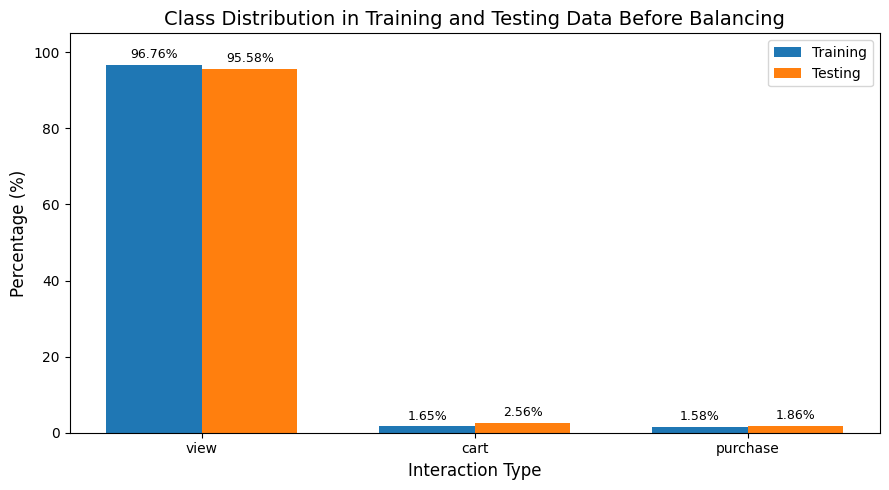

In [23]:
# ============================================================
# TRAINING AND TESTING CLASS DISTRIBUTION
# BEFORE BALANCING
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

events = ["view", "cart", "purchase"]

train_percentages = train_distribution["Percentage"].values
test_percentages = test_distribution["Percentage"].values

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(9, 5))

bars_train = plt.bar(
    x - width / 2,
    train_percentages,
    width,
    label="Training"
)

bars_test = plt.bar(
    x + width / 2,
    test_percentages,
    width,
    label="Testing"
)

plt.title(
    "Class Distribution in Training and Testing Data Before Balancing",
    fontsize=14
)

plt.xlabel("Interaction Type", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

plt.xticks(x, events)
plt.ylim(0, 105)

plt.legend()

# Add percentage labels
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_2_Class_Distribution_Train_Test_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# ============================================================
# PREPARING INPUTS FOR MODELS
# ============================================================

print("===== PREPARING MODEL INPUTS =====")

# ------------------------------------------------------------
# LSTM INPUTS
# ------------------------------------------------------------

X_train_lstm = X_train.copy()
X_test_lstm = X_test.copy()

y_train_lstm = y_train.copy()
y_test_lstm = y_test.copy()

print("\n===== LSTM INPUTS =====")

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape :", X_test_lstm.shape)

print("y_train_lstm shape:", y_train_lstm.shape)
print("y_test_lstm shape :", y_test_lstm.shape)

# ------------------------------------------------------------
# TRADITIONAL MODEL INPUTS
# ------------------------------------------------------------

X_train_traditional = X_train.copy()
X_test_traditional = X_test.copy()

y_train_traditional = y_train.copy()
y_test_traditional = y_test.copy()

print("\n===== TRADITIONAL MODEL INPUTS =====")

print(
    "X_train_traditional shape:",
    X_train_traditional.shape
)

print(
    "X_test_traditional shape :",
    X_test_traditional.shape
)

print(
    "y_train_traditional shape:",
    y_train_traditional.shape
)

print(
    "y_test_traditional shape :",
    y_test_traditional.shape
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n===== INPUT CONSISTENCY CHECK =====")

print(
    "LSTM and traditional X_train identical:",
    np.array_equal(
        X_train_lstm,
        X_train_traditional
    )
)

print(
    "LSTM and traditional X_test identical:",
    np.array_equal(
        X_test_lstm,
        X_test_traditional
    )
)

print(
    "LSTM and traditional y_train identical:",
    np.array_equal(
        y_train_lstm,
        y_train_traditional
    )
)

print(
    "LSTM and traditional y_test identical:",
    np.array_equal(
        y_test_lstm,
        y_test_traditional
    )
)

print("\n===== MODEL INPUT PREPARATION COMPLETED =====")

===== PREPARING MODEL INPUTS =====

===== LSTM INPUTS =====
X_train_lstm shape: (1888253, 5)
X_test_lstm shape : (472065, 5)
y_train_lstm shape: (1888253,)
y_test_lstm shape : (472065,)

===== TRADITIONAL MODEL INPUTS =====
X_train_traditional shape: (1888253, 5)
X_test_traditional shape : (472065, 5)
y_train_traditional shape: (1888253,)
y_test_traditional shape : (472065,)

===== INPUT CONSISTENCY CHECK =====
LSTM and traditional X_train identical: True
LSTM and traditional X_test identical: True
LSTM and traditional y_train identical: True
LSTM and traditional y_test identical: True

===== MODEL INPUT PREPARATION COMPLETED =====


In [26]:
# ============================================================
# BUILDING LSTM MODEL - BEFORE BALANCING
# ============================================================

print("===== BUILDING LSTM MODEL - BEFORE BALANCING =====")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

# Model configuration
VOCAB_SIZE = 3
SEQUENCE_LENGTH = 5
EMBEDDING_DIM = 8
LSTM_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
NUM_CLASSES = 3

# Build model
lstm_before = Sequential([
    Input(shape=(SEQUENCE_LENGTH,), dtype="int32"),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(LSTM_UNITS),

    Dropout(DROPOUT_RATE),

    Dense(DENSE_UNITS, activation="relu"),

    Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
lstm_before.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
print("\n===== LSTM MODEL SUMMARY =====")
lstm_before.summary()

===== BUILDING LSTM MODEL - BEFORE BALANCING =====

===== LSTM MODEL SUMMARY =====


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 5, 8)           │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,851 (22.86 KB)

 Trainable params: 5,851 (22.86 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ============================================================
# HARDWARE CHECK
# ============================================================

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:", gpus)
else:
    print("GPU not available - training will use CPU.")

TensorFlow version: 2.20.0
GPU not available - training will use CPU.


In [28]:
# ============================================================
# TRAINING LSTM - BEFORE BALANCING
# ============================================================

print("===== TRAINING LSTM - BEFORE BALANCING =====")

EPOCHS = 5
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

history_lstm_before = lstm_before.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    shuffle=True,
    verbose=1
)

print("\n===== LSTM TRAINING COMPLETED =====")


===== TRAINING LSTM - BEFORE BALANCING =====
Epoch 1/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.9705 - loss: 0.1199 - val_accuracy: 0.9646 - val_loss: 0.1353
Epoch 2/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.9711 - loss: 0.1143 - val_accuracy: 0.9644 - val_loss: 0.1355
Epoch 3/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.9711 - loss: 0.1138 - val_accuracy: 0.9648 - val_loss: 0.1373
Epoch 4/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.9712 - loss: 0.1136 - val_accuracy: 0.9647 - val_loss: 0.1351
Epoch 5/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.9712 - loss: 0.1134 - val_accuracy: 0.9647 - val_loss: 0.1355

===== LSTM TRAINING COMPLETED =====


In [29]:
# ============================================================
# LSTM PREDICTIONS - BEFORE BALANCING
# ============================================================

print("===== LSTM PREDICTIONS - BEFORE BALANCING =====")

y_pred_lstm_before_prob = lstm_before.predict(
    X_test_lstm,
    batch_size=256,
    verbose=1
)

y_pred_lstm_before = np.argmax(
    y_pred_lstm_before_prob,
    axis=1
)

print("\n===== PREDICTIONS COMPLETED =====")

print("Predictions shape:", y_pred_lstm_before.shape)
print("Expected shape   :", y_test_lstm.shape)

===== LSTM PREDICTIONS - BEFORE BALANCING =====
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

===== PREDICTIONS COMPLETED =====
Predictions shape: (472065,)
Expected shape   : (472065,)


In [34]:
# ============================================================
# LSTM PREDICTED CLASS DISTRIBUTION - BEFORE BALANCING
# ============================================================

print("===== LSTM PREDICTED CLASS DISTRIBUTION =====")

predicted_counts = pd.Series(
    y_pred_lstm_before
).value_counts().sort_index()

predicted_distribution = pd.DataFrame({
    "Event": ["view", "cart", "purchase"],
    "Code": [0, 1, 2],
    "Predicted Count": [
        predicted_counts.get(0, 0),
        predicted_counts.get(1, 0),
        predicted_counts.get(2, 0)
    ]
})

predicted_distribution["Percentage"] = (
    predicted_distribution["Predicted Count"]
    / len(y_pred_lstm_before)
    * 100
).round(2)

display(predicted_distribution)

===== LSTM PREDICTED CLASS DISTRIBUTION =====


,Event,Code,Predicted Count,Percentage
0,view,0,467066,98.94
1,cart,1,2888,0.61
2,purchase,2,2111,0.45


In [35]:
# ============================================================
# LSTM EVALUATION - BEFORE BALANCING
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("===== LSTM EVALUATION - BEFORE BALANCING =====")

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy_lstm_before = accuracy_score(
    y_test_lstm,
    y_pred_lstm_before
)

# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

precision_lstm_before = precision_score(
    y_test_lstm,
    y_pred_lstm_before,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Recall
# ------------------------------------------------------------

recall_lstm_before = recall_score(
    y_test_lstm,
    y_pred_lstm_before,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# F1-score
# ------------------------------------------------------------

f1_lstm_before = f1_score(
    y_test_lstm,
    y_pred_lstm_before,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(f"Accuracy : {accuracy_lstm_before:.4f}")
print(f"Precision: {precision_lstm_before:.4f}")
print(f"Recall   : {recall_lstm_before:.4f}")
print(f"F1-Score: {f1_lstm_before:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_lstm,
        y_pred_lstm_before,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\n===== CONFUSION MATRIX =====")

cm_lstm_before = confusion_matrix(
    y_test_lstm,
    y_pred_lstm_before
)

print(cm_lstm_before)

===== LSTM EVALUATION - BEFORE BALANCING =====
Accuracy : 0.9591
Precision: 0.9458
Recall   : 0.9591
F1-Score: 0.9463

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        view       0.96      1.00      0.98    451186
        cart       0.51      0.12      0.19     12105
    purchase       0.66      0.16      0.26      8774

    accuracy                           0.96    472065
   macro avg       0.71      0.43      0.48    472065
weighted avg       0.95      0.96      0.95    472065


===== CONFUSION MATRIX =====
[[449886    839    461]
 [ 10385   1460    260]
 [  6795    589   1390]]


In [36]:
# ============================================================
# LOGISTIC REGRESSION - BEFORE BALANCING
# ============================================================

print("===== BUILDING LOGISTIC REGRESSION - BEFORE BALANCING =====")

from sklearn.linear_model import LogisticRegression

logistic_before = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_before.fit(
    X_train_traditional,
    y_train_traditional
)

print("\n===== LOGISTIC REGRESSION TRAINING COMPLETED =====")

===== BUILDING LOGISTIC REGRESSION - BEFORE BALANCING =====

===== LOGISTIC REGRESSION TRAINING COMPLETED =====


In [37]:
# ============================================================
# LOGISTIC REGRESSION PREDICTIONS - BEFORE BALANCING
# ============================================================

print("===== LOGISTIC REGRESSION PREDICTIONS - BEFORE BALANCING =====")

y_pred_logistic_before = logistic_before.predict(
    X_test_traditional
)

print("\n===== PREDICTIONS COMPLETED =====")
print("Predictions shape:", y_pred_logistic_before.shape)
print("Expected shape   :", y_test_traditional.shape)

===== LOGISTIC REGRESSION PREDICTIONS - BEFORE BALANCING =====

===== PREDICTIONS COMPLETED =====
Predictions shape: (472065,)
Expected shape   : (472065,)


In [38]:
# ============================================================
# LOGISTIC REGRESSION EVALUATION - BEFORE BALANCING
# ============================================================

print("===== LOGISTIC REGRESSION EVALUATION - BEFORE BALANCING =====")

accuracy_logistic_before = accuracy_score(
    y_test_traditional,
    y_pred_logistic_before
)

precision_logistic_before = precision_score(
    y_test_traditional,
    y_pred_logistic_before,
    average="weighted",
    zero_division=0
)

recall_logistic_before = recall_score(
    y_test_traditional,
    y_pred_logistic_before,
    average="weighted",
    zero_division=0
)

f1_logistic_before = f1_score(
    y_test_traditional,
    y_pred_logistic_before,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_logistic_before:.4f}")
print(f"Precision: {precision_logistic_before:.4f}")
print(f"Recall   : {recall_logistic_before:.4f}")
print(f"F1-Score: {f1_logistic_before:.4f}")

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_logistic_before,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

print("\n===== CONFUSION MATRIX =====")

cm_logistic_before = confusion_matrix(
    y_test_traditional,
    y_pred_logistic_before
)

print(cm_logistic_before)

===== LOGISTIC REGRESSION EVALUATION - BEFORE BALANCING =====
Accuracy : 0.9541
Precision: 0.9296
Recall   : 0.9541
F1-Score: 0.9361

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        view       0.96      1.00      0.98    451186
        cart       0.52      0.05      0.09     12105
    purchase       0.07      0.01      0.02      8774

    accuracy                           0.95    472065
   macro avg       0.51      0.35      0.36    472065
weighted avg       0.93      0.95      0.94    472065


===== CONFUSION MATRIX =====
[[449731    430   1025]
 [ 11467    610     28]
 [  8557    139     78]]


In [39]:
# ============================================================
# DECISION TREE - BEFORE BALANCING
# ============================================================

print("===== BUILDING DECISION TREE - BEFORE BALANCING =====")

from sklearn.tree import DecisionTreeClassifier

decision_tree_before = DecisionTreeClassifier(
    random_state=42
)

decision_tree_before.fit(
    X_train_traditional,
    y_train_traditional
)

print("\n===== DECISION TREE TRAINING COMPLETED =====")

===== BUILDING DECISION TREE - BEFORE BALANCING =====

===== DECISION TREE TRAINING COMPLETED =====


In [40]:
# ============================================================
# DECISION TREE PREDICTIONS - BEFORE BALANCING
# ============================================================

print("===== DECISION TREE PREDICTIONS - BEFORE BALANCING =====")

y_pred_tree_before = decision_tree_before.predict(
    X_test_traditional
)

print("\n===== PREDICTIONS COMPLETED =====")
print("Predictions shape:", y_pred_tree_before.shape)
print("Expected shape   :", y_test_traditional.shape)

===== DECISION TREE PREDICTIONS - BEFORE BALANCING =====

===== PREDICTIONS COMPLETED =====
Predictions shape: (472065,)
Expected shape   : (472065,)


In [41]:
# ============================================================
# DECISION TREE EVALUATION - BEFORE BALANCING
# ============================================================

print("===== DECISION TREE EVALUATION - BEFORE BALANCING =====")

accuracy_tree_before = accuracy_score(
    y_test_traditional,
    y_pred_tree_before
)

precision_tree_before = precision_score(
    y_test_traditional,
    y_pred_tree_before,
    average="weighted",
    zero_division=0
)

recall_tree_before = recall_score(
    y_test_traditional,
    y_pred_tree_before,
    average="weighted",
    zero_division=0
)

f1_tree_before = f1_score(
    y_test_traditional,
    y_pred_tree_before,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_tree_before:.4f}")
print(f"Precision: {precision_tree_before:.4f}")
print(f"Recall   : {recall_tree_before:.4f}")
print(f"F1-Score: {f1_tree_before:.4f}")

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_tree_before,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

print("\n===== CONFUSION MATRIX =====")

cm_tree_before = confusion_matrix(
    y_test_traditional,
    y_pred_tree_before
)

print(cm_tree_before)

===== DECISION TREE EVALUATION - BEFORE BALANCING =====
Accuracy : 0.9590
Precision: 0.9458
Recall   : 0.9590
F1-Score: 0.9459

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        view       0.96      1.00      0.98    451186
        cart       0.53      0.11      0.18     12105
    purchase       0.64      0.16      0.26      8774

    accuracy                           0.96    472065
   macro avg       0.71      0.42      0.47    472065
weighted avg       0.95      0.96      0.95    472065


===== CONFUSION MATRIX =====
[[449997    698    491]
 [ 10493   1316    296]
 [  6885    471   1418]]


===== TRAIN VS TEST CLASS DISTRIBUTION - BEFORE BALANCING =====


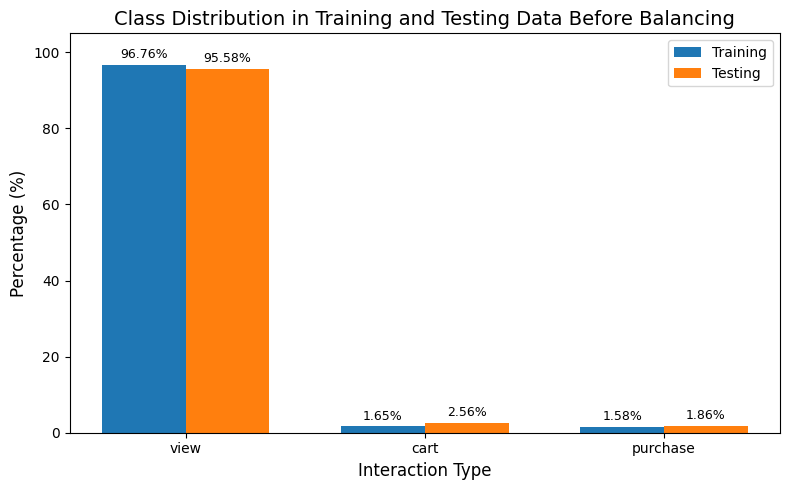

In [42]:
# ============================================================
# TRAIN VS TEST CLASS DISTRIBUTION - BEFORE BALANCING
# ============================================================

print("===== TRAIN VS TEST CLASS DISTRIBUTION - BEFORE BALANCING =====")

events = ["view", "cart", "purchase"]

train_percentages = train_distribution["Percentage"].values
test_percentages = test_distribution["Percentage"].values

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(8, 5))

bars_train = plt.bar(
    x - width / 2,
    train_percentages,
    width,
    label="Training"
)

bars_test = plt.bar(
    x + width / 2,
    test_percentages,
    width,
    label="Testing"
)

plt.title(
    "Class Distribution in Training and Testing Data Before Balancing",
    fontsize=14
)

plt.xlabel("Interaction Type", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

plt.xticks(x, events)
plt.ylim(0, 105)

plt.legend()

# Add percentage labels
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_2_Train_Test_Class_Distribution_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

===== MODEL COMPARISON - BEFORE BALANCING =====


,Model,Accuracy,Macro F1-Score
0,Logistic Regression,0.954146,0.361422
1,Decision Tree,0.959044,0.472832
2,LSTM,0.959054,0.476677


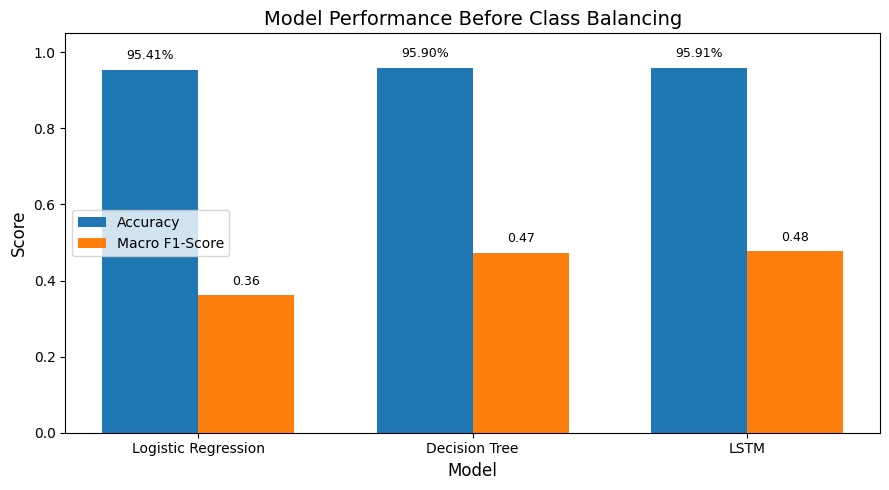

In [43]:
# ============================================================
# MODEL COMPARISON - BEFORE BALANCING
# ============================================================

print("===== MODEL COMPARISON - BEFORE BALANCING =====")

models = [
    "Logistic Regression",
    "Decision Tree",
    "LSTM"
]

accuracy_before = [
    accuracy_logistic_before,
    accuracy_tree_before,
    accuracy_lstm_before
]

macro_f1_before = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm,
        y_pred_lstm_before,
        average="macro",
        zero_division=0
    )
]

comparison_before = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_before,
    "Macro F1-Score": macro_f1_before
})

display(comparison_before)

# ============================================================
# VISUALIZATION
# ============================================================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

bars_accuracy = plt.bar(
    x - width / 2,
    accuracy_before,
    width,
    label="Accuracy"
)

bars_macro_f1 = plt.bar(
    x + width / 2,
    macro_f1_before,
    width,
    label="Macro F1-Score"
)

plt.title(
    "Model Performance Before Class Balancing",
    fontsize=14
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 1.05)

plt.legend()

# Accuracy labels
for bar, value in zip(bars_accuracy, accuracy_before):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Macro F1 labels
for bar, value in zip(bars_macro_f1, macro_f1_before):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "Figure_3_Model_Performance_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

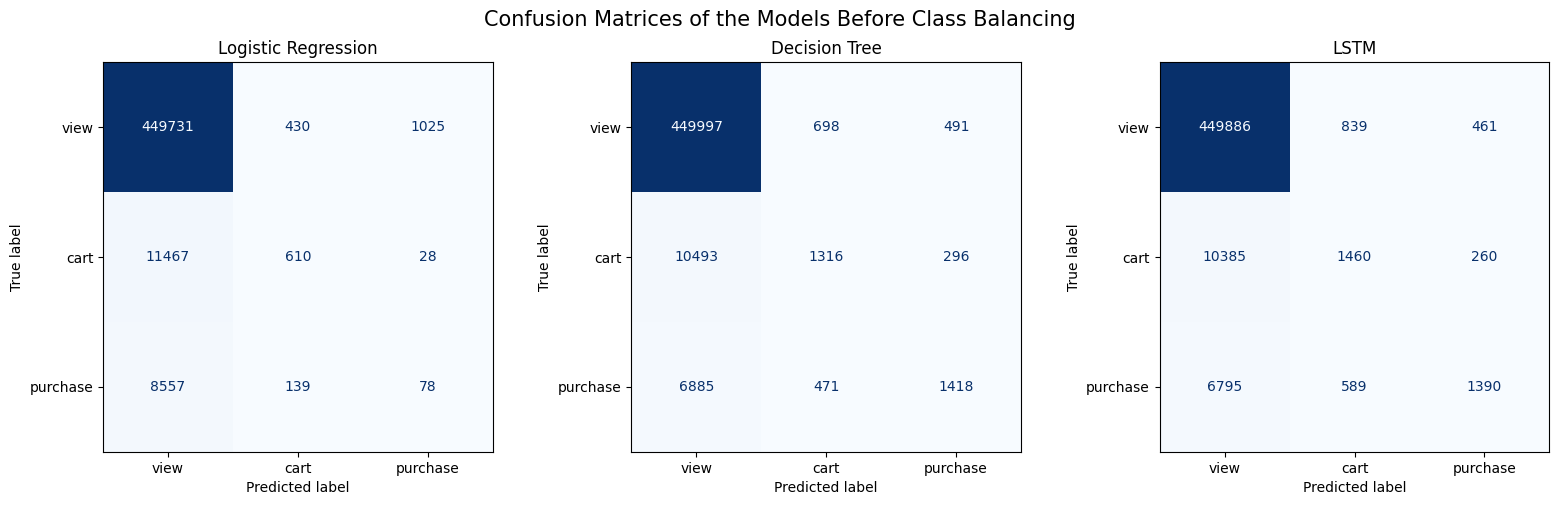

In [44]:
# ============================================================
# CONFUSION MATRICES - BEFORE BALANCING
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cm = [
    ("Logistic Regression", cm_logistic_before),
    ("Decision Tree", cm_tree_before),
    ("LSTM", cm_lstm_before)
]

for ax, (model_name, cm) in zip(axes, models_cm):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["view", "cart", "purchase"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle(
    "Confusion Matrices of the Models Before Class Balancing",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "Figure_4_Confusion_Matrices_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# ============================================================
# CLASS BALANCING - RANDOM UNDERSAMPLING
# ============================================================

print("===== CLASS BALANCING - RANDOM UNDERSAMPLING =====")

from imblearn.under_sampling import RandomUnderSampler

# ------------------------------------------------------------
# ORIGINAL TRAIN DISTRIBUTION
# ------------------------------------------------------------

print("\n===== BEFORE UNDERSAMPLING =====")

before_counts = pd.Series(y_train).value_counts().sort_index()

before_distribution = pd.DataFrame({
    "Code": [0, 1, 2],
    "Event": ["view", "cart", "purchase"],
    "Count": [
        before_counts.get(0, 0),
        before_counts.get(1, 0),
        before_counts.get(2, 0)
    ]
})

before_distribution["Percentage"] = (
    before_distribution["Count"]
    / len(y_train)
    * 100
).round(2)

display(before_distribution)

# ------------------------------------------------------------
# RANDOM UNDERSAMPLING
# ------------------------------------------------------------

print("\n===== APPLYING RANDOM UNDERSAMPLING =====")

undersampler = RandomUnderSampler(
    sampling_strategy="not minority",
    random_state=42
)

X_train_balanced, y_train_balanced = undersampler.fit_resample(
    X_train_traditional,
    y_train_traditional
)

# ------------------------------------------------------------
# BALANCED TRAIN DISTRIBUTION
# ------------------------------------------------------------

print("\n===== AFTER UNDERSAMPLING =====")

after_counts = pd.Series(y_train_balanced).value_counts().sort_index()

after_distribution = pd.DataFrame({
    "Code": [0, 1, 2],
    "Event": ["view", "cart", "purchase"],
    "Count": [
        after_counts.get(0, 0),
        after_counts.get(1, 0),
        after_counts.get(2, 0)
    ]
})

after_distribution["Percentage"] = (
    after_distribution["Count"]
    / len(y_train_balanced)
    * 100
).round(2)

display(after_distribution)

# ------------------------------------------------------------
# SHAPES
# ------------------------------------------------------------

print("\n===== BALANCED TRAIN SHAPES =====")

print("Original X_train shape :", X_train_traditional.shape)
print("Balanced X_train shape :", X_train_balanced.shape)

print("Original y_train shape :", y_train_traditional.shape)
print("Balanced y_train shape :", y_train_balanced.shape)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("\n===== BALANCING VALIDATION =====")

balanced_counts = pd.Series(y_train_balanced).value_counts()

print(
    "Balanced classes:",
    balanced_counts.nunique() == 1
)

print(
    "Test set unchanged:",
    len(y_test_traditional) == 472065
)

print(
    "Test distribution unchanged:",
    np.array_equal(
        y_test_traditional,
        y_test
    )
)

print("\n===== RANDOM UNDERSAMPLING COMPLETED =====")

===== CLASS BALANCING - RANDOM UNDERSAMPLING =====

===== BEFORE UNDERSAMPLING =====


,Code,Event,Count,Percentage
0,0,view,1827167,96.76
1,1,cart,31169,1.65
2,2,purchase,29917,1.58



===== APPLYING RANDOM UNDERSAMPLING =====

===== AFTER UNDERSAMPLING =====


,Code,Event,Count,Percentage
0,0,view,29917,33.33
1,1,cart,29917,33.33
2,2,purchase,29917,33.33



===== BALANCED TRAIN SHAPES =====
Original X_train shape : (1888253, 5)
Balanced X_train shape : (89751, 5)
Original y_train shape : (1888253,)
Balanced y_train shape : (89751,)

===== BALANCING VALIDATION =====
Balanced classes: True
Test set unchanged: True
Test distribution unchanged: True

===== RANDOM UNDERSAMPLING COMPLETED =====


===== CLASS DISTRIBUTION BEFORE AND AFTER BALANCING =====


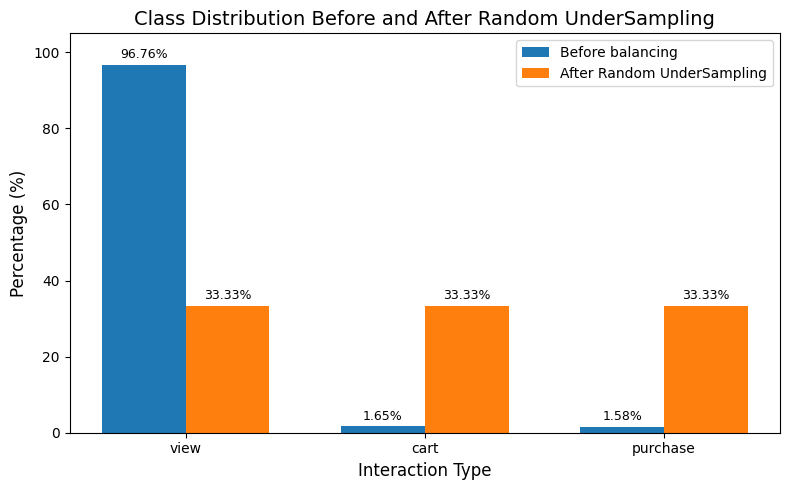

In [46]:
# ============================================================
# CLASS DISTRIBUTION BEFORE AND AFTER RANDOM UNDERSAMPLING
# ============================================================

print("===== CLASS DISTRIBUTION BEFORE AND AFTER BALANCING =====")

events = ["view", "cart", "purchase"]

before_percentages = before_distribution["Percentage"].values
after_percentages = after_distribution["Percentage"].values

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(8, 5))

bars_before = plt.bar(
    x - width / 2,
    before_percentages,
    width,
    label="Before balancing"
)

bars_after = plt.bar(
    x + width / 2,
    after_percentages,
    width,
    label="After Random UnderSampling"
)

plt.title(
    "Class Distribution Before and After Random UnderSampling",
    fontsize=14
)

plt.xlabel("Interaction Type", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

plt.xticks(x, events)
plt.ylim(0, 105)

plt.legend()

for bars in [bars_before, bars_after]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_5_Class_Distribution_Before_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# ============================================================
# PREPARING BALANCED TRAIN DATA FOR LSTM
# ============================================================

print("===== PREPARING BALANCED TRAIN DATA FOR LSTM =====")

# ------------------------------------------------------------
# BALANCED TRAIN DATA
# ------------------------------------------------------------

X_train_balanced_lstm = X_train_balanced.copy()
y_train_balanced_lstm = y_train_balanced.copy()

# ------------------------------------------------------------
# TEST DATA REMAINS ORIGINAL
# ------------------------------------------------------------

X_test_lstm_after = X_test_lstm.copy()
y_test_lstm_after = y_test_lstm.copy()

# ------------------------------------------------------------
# SHAPES
# ------------------------------------------------------------

print("\n===== BALANCED LSTM INPUTS =====")

print(
    "X_train_balanced_lstm shape:",
    X_train_balanced_lstm.shape
)

print(
    "y_train_balanced_lstm shape:",
    y_train_balanced_lstm.shape
)

print(
    "X_test_lstm_after shape:",
    X_test_lstm_after.shape
)

print(
    "y_test_lstm_after shape:",
    y_test_lstm_after.shape
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n===== BALANCED LSTM INPUT VALIDATION =====")

print(
    "X train/y train match:",
    X_train_balanced_lstm.shape[0]
    == y_train_balanced_lstm.shape[0]
)

print(
    "Sequence length correct:",
    X_train_balanced_lstm.shape[1]
    == SEQUENCE_LENGTH
)

print(
    "Test set unchanged:",
    X_test_lstm_after.shape
    == X_test_lstm.shape
)

print(
    "Test targets unchanged:",
    np.array_equal(
        y_test_lstm_after,
        y_test_lstm
    )
)

print("\n===== BALANCED LSTM INPUT PREPARATION COMPLETED =====")

===== PREPARING BALANCED TRAIN DATA FOR LSTM =====

===== BALANCED LSTM INPUTS =====
X_train_balanced_lstm shape: (89751, 5)
y_train_balanced_lstm shape: (89751,)
X_test_lstm_after shape: (472065, 5)
y_test_lstm_after shape: (472065,)

===== BALANCED LSTM INPUT VALIDATION =====
X train/y train match: True
Sequence length correct: True
Test set unchanged: True
Test targets unchanged: True

===== BALANCED LSTM INPUT PREPARATION COMPLETED =====


In [48]:
# ============================================================
# BUILDING LSTM MODEL - AFTER BALANCING
# ============================================================

print("===== BUILDING LSTM MODEL - AFTER BALANCING =====")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

# ------------------------------------------------------------
# MODEL CONFIGURATION
# Same architecture as LSTM before balancing
# ------------------------------------------------------------

VOCAB_SIZE = 3
SEQUENCE_LENGTH = 5
EMBEDDING_DIM = 8
LSTM_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
NUM_CLASSES = 3

# ------------------------------------------------------------
# BUILD NEW LSTM MODEL
# ------------------------------------------------------------

lstm_after = Sequential([
    Input(
        shape=(SEQUENCE_LENGTH,),
        dtype="int32"
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(LSTM_UNITS),

    Dropout(DROPOUT_RATE),

    Dense(
        DENSE_UNITS,
        activation="relu"
    ),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

lstm_after.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print("\n===== LSTM MODEL SUMMARY - AFTER BALANCING =====")

lstm_after.summary()

print("\n===== LSTM AFTER BALANCING MODEL READY =====")

===== BUILDING LSTM MODEL - AFTER BALANCING =====

===== LSTM MODEL SUMMARY - AFTER BALANCING =====


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 5, 8)           │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,851 (22.86 KB)

 Trainable params: 5,851 (22.86 KB)

 Non-trainable params: 0 (0.00 B)


===== LSTM AFTER BALANCING MODEL READY =====


In [49]:
# ============================================================
# TRAINING LSTM - AFTER BALANCING
# ============================================================

print("===== TRAINING LSTM - AFTER BALANCING =====")

EPOCHS = 5
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

history_lstm_after = lstm_after.fit(
    X_train_balanced_lstm,
    y_train_balanced_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    shuffle=True,
    verbose=1
)

print("\n===== LSTM TRAINING AFTER BALANCING COMPLETED =====")

===== TRAINING LSTM - AFTER BALANCING =====
Epoch 1/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6038 - loss: 0.8988 - val_accuracy: 0.4674 - val_loss: 1.0626
Epoch 2/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6437 - loss: 0.8350 - val_accuracy: 0.4756 - val_loss: 1.0336
Epoch 3/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6450 - loss: 0.8299 - val_accuracy: 0.5390 - val_loss: 1.0278
Epoch 4/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6453 - loss: 0.8265 - val_accuracy: 0.5342 - val_loss: 1.0025
Epoch 5/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6462 - loss: 0.8248 - val_accuracy: 0.5391 - val_loss: 1.0102

===== LSTM TRAINING AFTER BALANCING COMPLETED =====


In [50]:
# ============================================================
# LSTM PREDICTIONS - AFTER BALANCING
# ============================================================

print("===== LSTM PREDICTIONS - AFTER BALANCING =====")

y_pred_lstm_after_prob = lstm_after.predict(
    X_test_lstm_after,
    batch_size=256,
    verbose=1
)

# Convert probabilities to predicted classes
y_pred_lstm_after = np.argmax(
    y_pred_lstm_after_prob,
    axis=1
)

print("\n===== PREDICTIONS COMPLETED =====")

print(
    "Predictions shape:",
    y_pred_lstm_after.shape
)

print(
    "Expected shape   :",
    y_test_lstm_after.shape
)

===== LSTM PREDICTIONS - AFTER BALANCING =====
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

===== PREDICTIONS COMPLETED =====
Predictions shape: (472065,)
Expected shape   : (472065,)


In [51]:
# ============================================================
# LSTM EVALUATION - AFTER BALANCING
# ============================================================

print("===== LSTM EVALUATION - AFTER BALANCING =====")

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy_lstm_after = accuracy_score(
    y_test_lstm_after,
    y_pred_lstm_after
)

precision_lstm_after = precision_score(
    y_test_lstm_after,
    y_pred_lstm_after,
    average="weighted",
    zero_division=0
)

recall_lstm_after = recall_score(
    y_test_lstm_after,
    y_pred_lstm_after,
    average="weighted",
    zero_division=0
)

f1_lstm_after = f1_score(
    y_test_lstm_after,
    y_pred_lstm_after,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_lstm_after:.4f}")
print(f"Precision: {precision_lstm_after:.4f}")
print(f"Recall   : {recall_lstm_after:.4f}")
print(f"F1-Score: {f1_lstm_after:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_lstm_after,
        y_pred_lstm_after,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("===== CONFUSION MATRIX =====")

cm_lstm_after = confusion_matrix(
    y_test_lstm_after,
    y_pred_lstm_after
)

print(cm_lstm_after)

print("\n===== LSTM EVALUATION AFTER BALANCING COMPLETED =====")

===== LSTM EVALUATION - AFTER BALANCING =====
Accuracy : 0.9102
Precision: 0.9507
Recall   : 0.9102
F1-Score: 0.9273

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        view       0.98      0.93      0.96    451186
        cart       0.21      0.52      0.30     12105
    purchase       0.28      0.52      0.36      8774

    accuracy                           0.91    472065
   macro avg       0.49      0.66      0.54    472065
weighted avg       0.95      0.91      0.93    472065

===== CONFUSION MATRIX =====
[[418720  21831  10635]
 [  4297   6354   1454]
 [  2694   1490   4590]]

===== LSTM EVALUATION AFTER BALANCING COMPLETED =====


In [52]:
# ============================================================
# LOGISTIC REGRESSION - AFTER BALANCING
# ============================================================

print("===== BUILDING LOGISTIC REGRESSION - AFTER BALANCING =====")

from sklearn.linear_model import LogisticRegression

logistic_after = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_after.fit(
    X_train_balanced,
    y_train_balanced
)

print("===== LOGISTIC REGRESSION TRAINING AFTER BALANCING COMPLETED =====")

===== BUILDING LOGISTIC REGRESSION - AFTER BALANCING =====
===== LOGISTIC REGRESSION TRAINING AFTER BALANCING COMPLETED =====


In [54]:
# ============================================================
# LOGISTIC REGRESSION PREDICTIONS - AFTER BALANCING
# ============================================================

print("===== LOGISTIC REGRESSION PREDICTIONS - AFTER BALANCING =====")

y_pred_logistic_after = logistic_after.predict(
    X_test_traditional
)

print("\n===== PREDICTIONS COMPLETED =====")
print(
    "Predictions shape:",
    y_pred_logistic_after.shape
)
print(
    "Expected shape   :",
    y_test_traditional.shape
)

===== LOGISTIC REGRESSION PREDICTIONS - AFTER BALANCING =====

===== PREDICTIONS COMPLETED =====
Predictions shape: (472065,)
Expected shape   : (472065,)


In [55]:
# ============================================================
# LOGISTIC REGRESSION EVALUATION - AFTER BALANCING
# ============================================================

print("===== LOGISTIC REGRESSION EVALUATION - AFTER BALANCING =====")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy_logistic_after = accuracy_score(
    y_test_traditional,
    y_pred_logistic_after
)

precision_logistic_after = precision_score(
    y_test_traditional,
    y_pred_logistic_after,
    average="weighted",
    zero_division=0
)

recall_logistic_after = recall_score(
    y_test_traditional,
    y_pred_logistic_after,
    average="weighted",
    zero_division=0
)

f1_logistic_after = f1_score(
    y_test_traditional,
    y_pred_logistic_after,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_logistic_after:.4f}")
print(f"Precision: {precision_logistic_after:.4f}")
print(f"Recall   : {recall_logistic_after:.4f}")
print(f"F1-Score: {f1_logistic_after:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_logistic_after,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("===== CONFUSION MATRIX =====")

cm_logistic_after = confusion_matrix(
    y_test_traditional,
    y_pred_logistic_after
)

print(cm_logistic_after)

print("\n===== LOGISTIC REGRESSION EVALUATION COMPLETED =====")

===== LOGISTIC REGRESSION EVALUATION - AFTER BALANCING =====
Accuracy : 0.9043
Precision: 0.9494
Recall   : 0.9043
F1-Score: 0.9235

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        view       0.98      0.92      0.95    451186
        cart       0.22      0.47      0.30     12105
    purchase       0.19      0.51      0.28      8774

    accuracy                           0.90    472065
   macro avg       0.47      0.63      0.51    472065
weighted avg       0.95      0.90      0.92    472065

===== CONFUSION MATRIX =====
[[416773  18018  16395]
 [  4297   5654   2154]
 [  2690   1608   4476]]

===== LOGISTIC REGRESSION EVALUATION COMPLETED =====


In [57]:
# ============================================================
# DECISION TREE - AFTER BALANCING
# ============================================================

print("===== BUILDING DECISION TREE - AFTER BALANCING =====")

from sklearn.tree import DecisionTreeClassifier

decision_tree_after = DecisionTreeClassifier(
    random_state=42
)

decision_tree_after.fit(
    X_train_balanced,
    y_train_balanced
)

print("===== DECISION TREE TRAINING AFTER BALANCING COMPLETED =====")

===== BUILDING DECISION TREE - AFTER BALANCING =====
===== DECISION TREE TRAINING AFTER BALANCING COMPLETED =====


In [58]:
# ============================================================
# DECISION TREE PREDICTIONS - AFTER BALANCING
# ============================================================

print("===== DECISION TREE PREDICTIONS - AFTER BALANCING =====")

y_pred_tree_after = decision_tree_after.predict(
    X_test_traditional
)

print("\n===== PREDICTIONS COMPLETED =====")

print(
    "Predictions shape:",
    y_pred_tree_after.shape
)

print(
    "Expected shape   :",
    y_test_traditional.shape
)

===== DECISION TREE PREDICTIONS - AFTER BALANCING =====

===== PREDICTIONS COMPLETED =====
Predictions shape: (472065,)
Expected shape   : (472065,)


In [59]:
# ============================================================
# DECISION TREE EVALUATION - AFTER BALANCING
# ============================================================

print("===== DECISION TREE EVALUATION - AFTER BALANCING =====")

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy_tree_after = accuracy_score(
    y_test_traditional,
    y_pred_tree_after
)

precision_tree_after = precision_score(
    y_test_traditional,
    y_pred_tree_after,
    average="weighted",
    zero_division=0
)

recall_tree_after = recall_score(
    y_test_traditional,
    y_pred_tree_after,
    average="weighted",
    zero_division=0
)

f1_tree_after = f1_score(
    y_test_traditional,
    y_pred_tree_after,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_tree_after:.4f}")
print(f"Precision: {precision_tree_after:.4f}")
print(f"Recall   : {recall_tree_after:.4f}")
print(f"F1-Score: {f1_tree_after:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_tree_after,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("===== CONFUSION MATRIX =====")

cm_tree_after = confusion_matrix(
    y_test_traditional,
    y_pred_tree_after
)

print(cm_tree_after)

print("\n===== DECISION TREE EVALUATION COMPLETED =====")

===== DECISION TREE EVALUATION - AFTER BALANCING =====
Accuracy : 0.9176
Precision: 0.9516
Recall   : 0.9176
F1-Score: 0.9319

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        view       0.98      0.94      0.96    451186
        cart       0.24      0.51      0.32     12105
    purchase       0.29      0.56      0.38      8774

    accuracy                           0.92    472065
   macro avg       0.50      0.67      0.55    472065
weighted avg       0.95      0.92      0.93    472065

===== CONFUSION MATRIX =====
[[422102  18505  10579]
 [  4311   6120   1674]
 [  2699   1145   4930]]

===== DECISION TREE EVALUATION COMPLETED =====


===== FINAL MODEL COMPARISON - BEFORE VS AFTER BALANCING =====


,Model,Accuracy Before,Accuracy After,Macro F1 Before,Macro F1 After
0,Logistic Regression,0.954146,0.904331,0.361422,0.512225
1,Decision Tree,0.959044,0.917569,0.472832,0.554008
2,LSTM,0.959054,0.910180,0.476677,0.539944


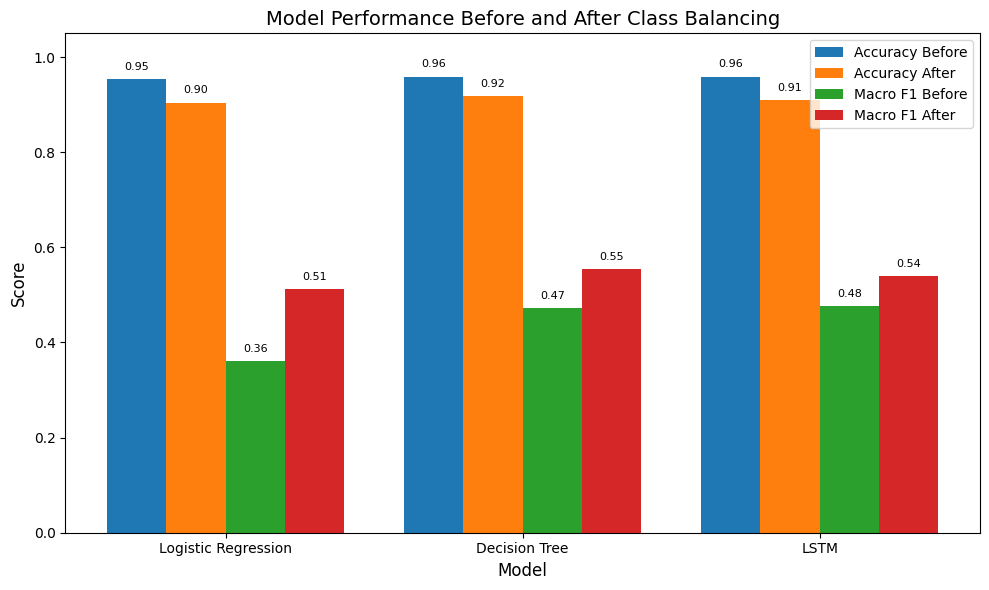

In [60]:
# ============================================================
# FINAL MODEL COMPARISON - BEFORE VS AFTER BALANCING
# ============================================================

print("===== FINAL MODEL COMPARISON - BEFORE VS AFTER BALANCING =====")

models = [
    "Logistic Regression",
    "Decision Tree",
    "LSTM"
]

# Accuracy
accuracy_before = [
    accuracy_logistic_before,
    accuracy_tree_before,
    accuracy_lstm_before
]

accuracy_after = [
    accuracy_logistic_after,
    accuracy_tree_after,
    accuracy_lstm_after
]

# Macro F1
macro_f1_before = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm,
        y_pred_lstm_before,
        average="macro",
        zero_division=0
    )
]

macro_f1_after = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_after,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_after,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm_after,
        y_pred_lstm_after,
        average="macro",
        zero_division=0
    )
]

# Create summary table
final_comparison = pd.DataFrame({
    "Model": models,
    "Accuracy Before": accuracy_before,
    "Accuracy After": accuracy_after,
    "Macro F1 Before": macro_f1_before,
    "Macro F1 After": macro_f1_after
})

display(final_comparison)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - 1.5 * width,
    accuracy_before,
    width,
    label="Accuracy Before"
)

bars2 = plt.bar(
    x - 0.5 * width,
    accuracy_after,
    width,
    label="Accuracy After"
)

bars3 = plt.bar(
    x + 0.5 * width,
    macro_f1_before,
    width,
    label="Macro F1 Before"
)

bars4 = plt.bar(
    x + 1.5 * width,
    macro_f1_after,
    width,
    label="Macro F1 After"
)

plt.title(
    "Model Performance Before and After Class Balancing",
    fontsize=14
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 1.05)

plt.legend()

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "Figure_6_Final_Model_Comparison_Before_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

===== MINORITY CLASS RECALL COMPARISON =====


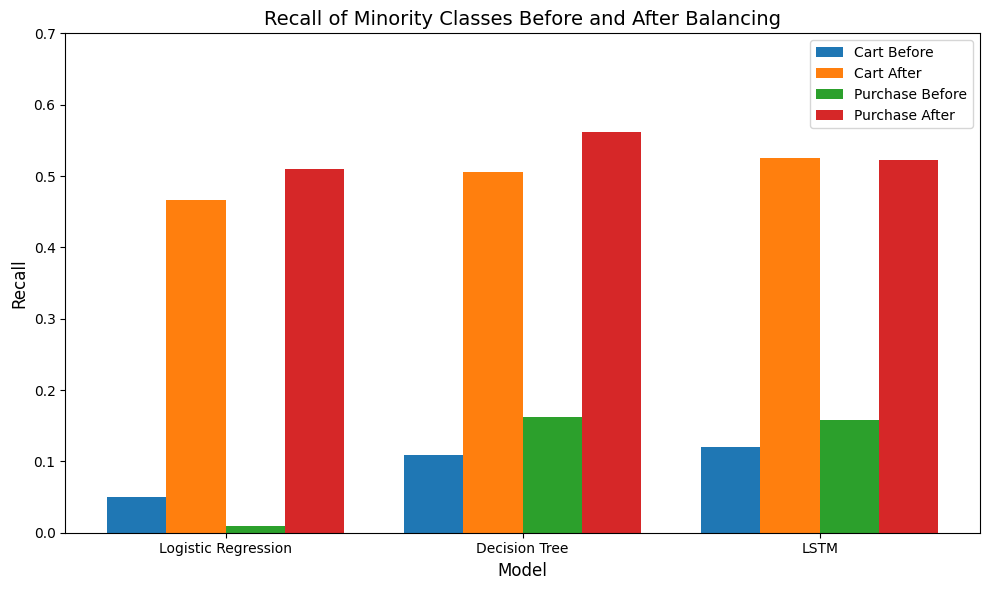

In [61]:
# ============================================================
# MINORITY CLASS RECALL - BEFORE VS AFTER BALANCING
# ============================================================

print("===== MINORITY CLASS RECALL COMPARISON =====")

cart_recall_before = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_before,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_before,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm,
        y_pred_lstm_before,
        labels=[1],
        average="macro",
        zero_division=0
    )
]

cart_recall_after = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_after,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_after,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm_after,
        y_pred_lstm_after,
        labels=[1],
        average="macro",
        zero_division=0
    )
]

purchase_recall_before = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_before,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_before,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm,
        y_pred_lstm_before,
        labels=[2],
        average="macro",
        zero_division=0
    )
]

purchase_recall_after = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_after,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_after,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm_after,
        y_pred_lstm_after,
        labels=[2],
        average="macro",
        zero_division=0
    )
]

x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(10, 6))

plt.bar(
    x - 1.5 * width,
    cart_recall_before,
    width,
    label="Cart Before"
)

plt.bar(
    x - 0.5 * width,
    cart_recall_after,
    width,
    label="Cart After"
)

plt.bar(
    x + 0.5 * width,
    purchase_recall_before,
    width,
    label="Purchase Before"
)

plt.bar(
    x + 1.5 * width,
    purchase_recall_after,
    width,
    label="Purchase After"
)

plt.title(
    "Recall of Minority Classes Before and After Balancing",
    fontsize=14
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("Recall", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 0.70)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_7_Minority_Class_Recall_Before_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

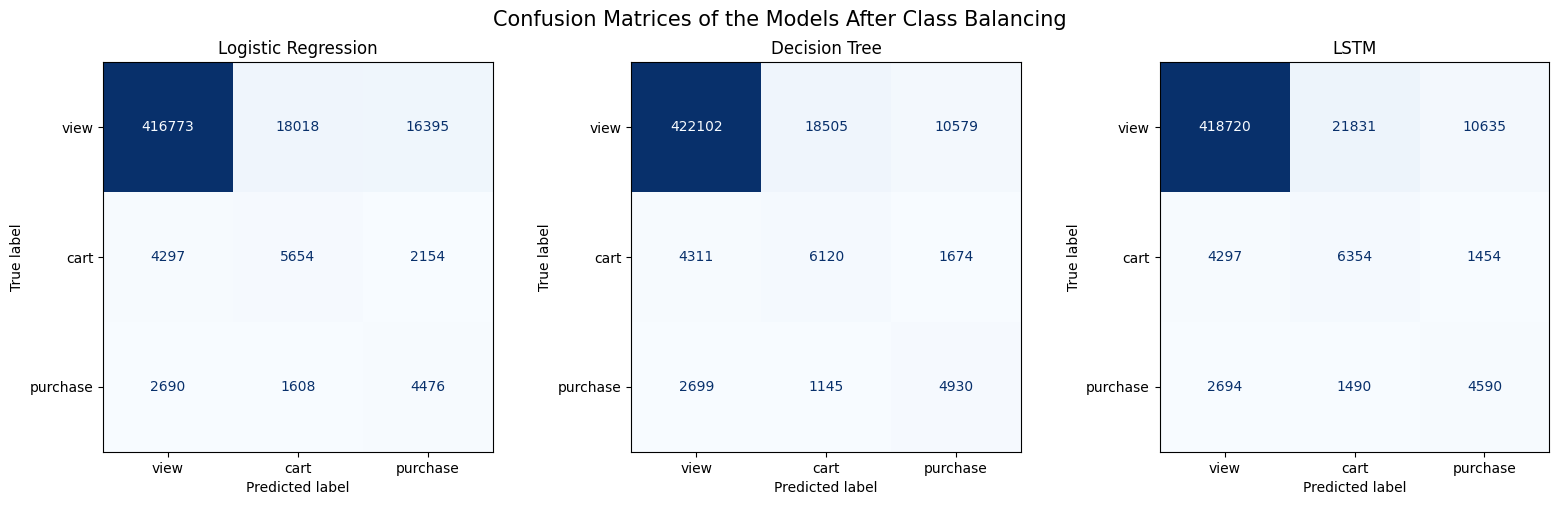

In [62]:
# ============================================================
# CONFUSION MATRICES - AFTER BALANCING
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cm_after = [
    ("Logistic Regression", cm_logistic_after),
    ("Decision Tree", cm_tree_after),
    ("LSTM", cm_lstm_after)
]

for ax, (model_name, cm) in zip(axes, models_cm_after):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["view", "cart", "purchase"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle(
    "Confusion Matrices of the Models After Class Balancing",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "Figure_8_Confusion_Matrices_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()